In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("/content/iqr_practice_dataset.csv")
print("shape",df.shape)
df.head()

shape (220, 10)


,Customer_ID,Age,Gender,City,Monthly_Income,Monthly_Spend,Transactions_Per_Month,Tenure_Months,Credit_Score,High_Risk
0,1001,49,F,Nagpur,68209.0,9454.0,21,32,713,0
1,1002,30,F,Nashik,96326.0,16797.0,25,11,575,1
2,1003,34,M,Nagpur,61049.0,12421.0,23,86,654,0
3,1004,38,F,Pune,60909.0,12007.0,16,85,707,0
4,1005,27,F,Aurangabad,46278.0,60.0,14,102,826,0


In [ ]:
print(df["High_Risk"].value_counts())

High_Risk
0    196
1     24
Name: count, dtype: int64


In [ ]:
corr=df.corr(numeric_only=True)["High_Risk"]
#sort by aboslute correlation
top_features=corr.abs().sort_values(ascending=False)
print("Top 10 important features:")
print(top_features.head(10))

Top 10 important features:
High_Risk                 1.000000
Credit_Score              0.404447
Transactions_Per_Month    0.280366
Monthly_Spend             0.258954
Monthly_Income            0.117867
Customer_ID               0.042702
Age                       0.021668
Tenure_Months             0.007478
Name: High_Risk, dtype: float64


In [ ]:
important_cols=top_features.head(10).index.tolist()
print("Top 5 selected features:",important_cols)

Top 5 selected features: ['High_Risk', 'Credit_Score', 'Transactions_Per_Month', 'Monthly_Spend', 'Monthly_Income', 'Customer_ID', 'Age', 'Tenure_Months']


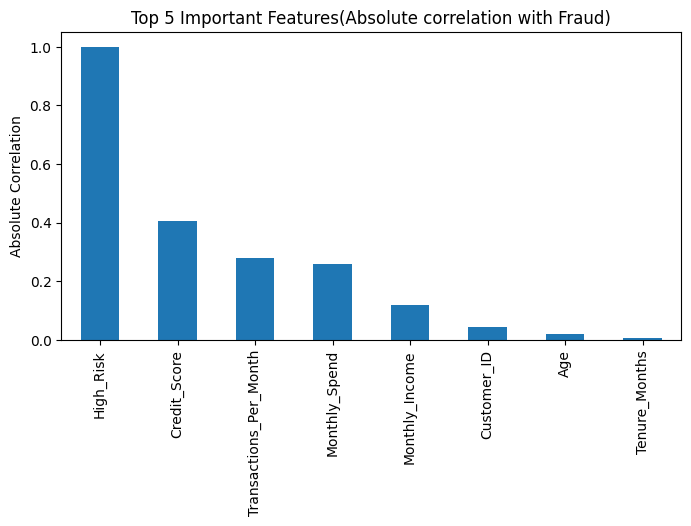

In [ ]:
plt.figure(figsize=(8,4))
top_features.head(10).plot(kind="bar")
plt.title("Top 5 Important Features(Absolute correlation with Fraud)")
plt.ylabel("Absolute Correlation")
plt.show()

In [ ]:
def iqr_outlier(series):
  Q1=series.quantile(0.25)     #finds the 25th percentile
  Q3=series.quantile(0.75)     #finds the 75th percentile
  IQR = Q3-Q1

  lower=Q1-1.5*IQR
  upper=Q3+1.5*IQR

  return(series<lower)|(series>upper)

In [ ]:
df_iqr = df.copy()

for col in important_cols:
  df_iqr[col+"_IQR_Outlier"]=iqr_outlier(df_iqr[col]).astype(int)

df_iqr.head(20)

,Customer_ID,Age,Gender,City,Monthly_Income,Monthly_Spend,Transactions_Per_Month,Tenure_Months,Credit_Score,High_Risk,High_Risk_IQR_Outlier,Credit_Score_IQR_Outlier,Transactions_Per_Month_IQR_Outlier,Monthly_Spend_IQR_Outlier,Monthly_Income_IQR_Outlier,Customer_ID_IQR_Outlier,Age_IQR_Outlier,Tenure_Months_IQR_Outlier
0,1001,49,F,Nagpur,68209.0,9454.0,21,32,713,0,0,0,0,0,0,0,0,0
1,1002,30,F,Nashik,96326.0,16797.0,25,11,575,1,1,0,0,0,0,0,0,0
2,1003,34,M,Nagpur,61049.0,12421.0,23,86,654,0,0,0,0,0,0,0,0,0
3,1004,38,F,Pune,60909.0,12007.0,16,85,707,0,0,0,0,0,0,0,0,0
4,1005,27,F,Aurangabad,46278.0,60.0,14,102,826,0,0,0,0,0,0,0,0,0
5,1006,34,NaN,Aurangabad,65410.0,14305.0,23,80,808,0,0,0,0,0,0,0,0,0
6,1007,34,M,Mumbai,77291.0,15651.0,27,83,574,1,1,0,0,0,0,0,0,0
7,1008,18,M,Pune,51675.0,11564.0,22,82,725,0,0,0,0,0,0,0,0,0
8,1009,43,M,Nagpur,64106.0,10226.0,28,80,634,0,0,0,0,0,0,0,0,0
9,1010,39,F,Nagpur,5000.0,100.0,18,94,662,1,1,0,0,0,1,0,0,0


In [ ]:
iqr_outlie_cols=[col+"_IQR_Outlier" for col in important_cols]

df_iqr["IQR_Anomly"]=(df_iqr[iqr_outlie_cols].sum(axis=1)>0).astype(int)
print("Total IQR anomalies:",df_iqr["IQR_Anomly"].sum())

Total IQR anomalies: 33


In [ ]:
total_fraud=df_iqr[df_iqr["High_Risk"]==1].shape[0]
iqr_fraud_detected=df_iqr[(df_iqr["IQR_Anomly"]==1) & (df_iqr["High_Risk"]==1)].shape[0]
(df_iqr["High_Risk"]==1).shape[0]

print("Total Fraudulent Transactions:",total_fraud)
print("Frauds Detected as IQR anomalies:",iqr_fraud_detected)

Total Fraudulent Transactions: 24
Frauds Detected as IQR anomalies: 24
